# Classification PFAS — Modèles Hybrides HGT + XGBoost (EPA 2024)

**Reproduction** du notebook `PFAS_Hybrid_HGT_XGBoost_prediction` sur le dataset
**CA-PFAS-ASGWS** avec la **même cible et le même seuil** que
`01_binary_classification_epa2024.ipynb` (EPA 2024 NPDWR : dépassement d'un MCL
individuel **ou** Indice de Risque du mélange > 1). Les colonnes de *features*
ont été **adaptées** aux variables disponibles dans ce dataset.

**Version REDUCED-FEATURE** : les concentrations PFAS (`*_ngL`) et indicateurs de
détection (`*_detected`, `label_*`) sont **exclus** (ils fondent la cible → fuite).
On démontre la capacité prédictive sur des puits *non encore analysés en laboratoire*.

### 20 features contextuelles (4 groupes)
| Groupe (PDF original) | Colonnes CA-PFAS-ASGWS |
|---|---|
| **Environmental** (6) | `rainfall_mm_month`, `runoff_mm`, `soil_moisture_total_mm`, `soil_sand_pct`, `soil_silt_pct`, `sand_silt_ratio`* |
| **Facility_Proximity** (6) | `dist_geotracker_km`, `n_geotracker_within_{1,3,10,50}km`, `geotracker_proximity`* |
| **Water_Quality** (6) | `cocontam_tds`, `cocontam_no3n`, `cocontam_so4`, `cocontam_tce`, `cocontam_pce`, `cocontam_mtbe` |
| **Geospatial** (2) | `latitude`, `longitude` |

\* features dérivées (ingénierie).

### Deux stratégies hybrides
1. **Embedding Fusion** : Données → HGT → embeddings (PCA) → \[embeddings + features\] → XGBoost
2. **Stacking Ensemble** : (HGT, XGBoost, LightGBM) → méta-features enrichies → méta-classifieur

> **Noyau requis** : l'environnement avec PyTorch + PyTorch Geometric
> (`pfas_total_prediction/.venv`, Python 3.10). Le dataset est lu en CSV pour
> éviter la dépendance `pyarrow`.

## 1. Imports et configuration

In [ ]:
import warnings, json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

# PyTorch + PyTorch Geometric
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau
try:
    from torch_geometric.data import HeteroData
    from torch_geometric.nn import HGTConv, Linear
    TORCH_GEOMETRIC_AVAILABLE = True
    print('PyTorch Geometric disponible')
except ImportError:
    TORCH_GEOMETRIC_AVAILABLE = False
    print('PyTorch Geometric NON disponible')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score, precision_score, recall_score,
    roc_curve, precision_recall_curve, average_precision_score)
from sklearn.calibration import calibration_curve
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
np.random.seed(42); torch.manual_seed(42)

# Chemins
PROJECT_ROOT = Path('..')
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR = PROJECT_ROOT / 'reports' / 'figures' / 'hgt_hybrid'
RES_DIR = PROJECT_ROOT / 'outputs' / 'hgt_hybrid'
MODELS_DIR = PROJECT_ROOT / 'models'
for d in (FIG_DIR, RES_DIR, MODELS_DIR): d.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
EPOCHS_HGT = 120          # epochs d'entraînement HGT
RUN_OPTUNA_HGT = True   # True = recherche d'hyperparamètres HGT (lent, ~1h)
N_TRIALS = 15            # essais Optuna pour les XGBoost (fusion / stacking)

print(f'Device: {device} | torch {torch.__version__}')

ImportError: Error importing numpy: you should not try to import numpy from
        its source directory; please exit the numpy source tree, and relaunch
        your python interpreter from there.

In [ ]:
# --- v2 : config graphe mécaniste + évaluation spatiale honnête ---
from scipy.spatial import cKDTree
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
SPATIAL_CV_K         = 8       # nb de blocs spatiaux (KMeans sur lat/lon)
GEOTRACKER_RADIUS_KM = 10.0    # rayon de rattachement puits <-> site GeoTracker
UPGRAD_THRESH        = 0.30    # seuil d'alignement pour une arête "site en amont hydraulique"
RUN_HGT_SPATIAL_CV   = True    # HGT mécaniste en CV spatiale (CPU : ~1-2 h). False = XGBoost seul (rapide).
HGT_CV_EPOCHS        = 40
print('Config v2 OK | blocs spatiaux =', SPATIAL_CV_K, '| rayon GeoTracker =', GEOTRACKER_RADIUS_KM, 'km')


## 2. Chargement des données et cible EPA 2024

Même dataset (`CA-PFAS-ASGWS`) et **même seuil** que le notebook de classification
binaire de référence.

In [ ]:
df = pd.read_csv(PROCESSED_DIR / 'CA-PFAS-ASGWS.csv')

EPA2024_MCLS = {'PFOA_ngL':4.0,'PFOS_ngL':4.0,'PFNA_ngL':10.0,'PFHxS_ngL':10.0,'HFPO_DA_ngL':10.0}
HI_REFS      = {'PFNA_ngL':10.0,'PFHxS_ngL':10.0,'HFPO_DA_ngL':10.0,'PFBS_ngL':2000.0}

def compute_target_epa2024(d):
    exceeded = pd.Series(False, index=d.index)
    for col, mcl in EPA2024_MCLS.items():
        if col in d.columns: exceeded |= d[col].fillna(0) > mcl
    hi = sum(d[c].fillna(0)/r for c, r in HI_REFS.items() if c in d.columns)
    exceeded |= hi > 1.0
    return exceeded.astype(int)

df['is_contaminated'] = compute_target_epa2024(df)
print(f'Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(df['is_contaminated'].value_counts())
print(f"Class 0: {(df.is_contaminated==0).sum()} ({(df.is_contaminated==0).mean()*100:.1f}%)")
print(f"Class 1: {(df.is_contaminated==1).sum()} ({(df.is_contaminated==1).mean()*100:.1f}%)")

Dataset : 46,338 lignes x 202 colonnes
is_contaminated
0    25184
1    21154
Name: count, dtype: int64
Class 0: 25184 (54.3%)
Class 1: 21154 (45.7%)


## 2bis. Enrichissement hydrogéologique — gradient hydraulique (DWR Periodic GWL)

Ajout d'une feature **mécaniste** : le gradient hydraulique local, dérivé d'une surface
piézométrique interpolée à partir des **niveaux de nappe DWR** (Periodic Groundwater Level,
champ `gwe` 2018+, 12 563 stations). Pour chaque puits : magnitude du gradient (‰), direction
d'écoulement (vecteur unitaire `flow_dir_sin`/`flow_dir_cos`), distance à la station GWL la plus
proche. Calcul **indépendant de la cible** (aucune fuite). Préparation hors notebook →
`data/processed/well_hydraulic_gradient.csv`.

In [ ]:
# Fusion du gradient hydraulique (préparé hors notebook depuis les niveaux DWR Periodic GWL)
_grad = pd.read_csv(PROCESSED_DIR / 'well_hydraulic_gradient.csv')
_hcols = ['hydr_grad_mag_permil', 'flow_dir_sin', 'flow_dir_cos', 'dist_nearest_gwl_km']
df = df.merge(_grad[['gm_well_id'] + _hcols], on='gm_well_id', how='left')
_cap = df['hydr_grad_mag_permil'].quantile(0.99)          # winsorise les fits planaires bruités
df['hydr_grad_mag_permil'] = df['hydr_grad_mag_permil'].clip(upper=_cap).fillna(df['hydr_grad_mag_permil'].median())
df['flow_dir_sin'] = df['flow_dir_sin'].fillna(0.0)
df['flow_dir_cos'] = df['flow_dir_cos'].fillna(0.0)
df['dist_nearest_gwl_km'] = df['dist_nearest_gwl_km'].fillna(df['dist_nearest_gwl_km'].median())
print(f"Gradient hydraulique fusionné — couverture {df['hydr_grad_mag_permil'].notna().mean():.1%} "
      f"| puits à <5 km d'une station GWL : {(df['dist_nearest_gwl_km'] < 5).mean():.1%}")
print(df[_hcols].describe().round(3).to_string())


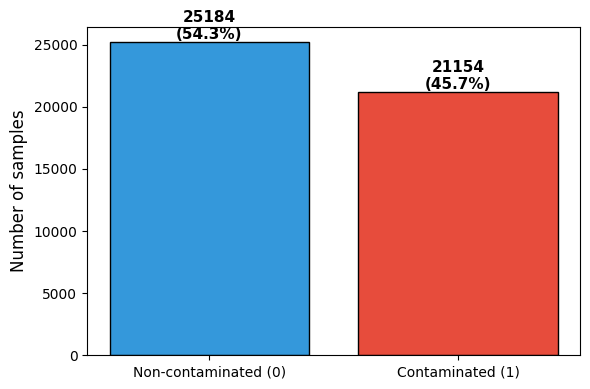

In [ ]:
# Figure 1 — distribution des classes
counts = df['is_contaminated'].value_counts().sort_index()
labels = ['Non-contaminated (0)', 'Contaminated (1)']
fig, ax = plt.subplots(figsize=(6,4))
bars = ax.bar(labels, counts.values, color=['#3498db','#e74c3c'], edgecolor='black')
ax.set_ylabel('Number of samples', fontsize=12)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height(),
            f'{val}\n({100*val/len(df):.1f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Ingénierie et catégorisation des features (Domain Knowledge)

**Version REDUCED-FEATURE** : aucune concentration PFAS. Deux features sont dérivées
pour reproduire les variables `Sand_Silt_Ratio` et `High_Risk_Proximity` du notebook original.

In [ ]:
# Features dérivées (équivalents des Sand_Silt_Ratio / High_Risk_Proximity du PDF)
df['sand_silt_ratio']     = df['soil_sand_pct'] / (df['soil_silt_pct'] + 1e-6)
df['geotracker_proximity'] = 1.0 / (1.0 + df['dist_geotracker_km'])

FEATURE_CATEGORIES = {
    'Environmental': ['rainfall_mm_month', 'runoff_mm', 'soil_moisture_total_mm',
                      'soil_sand_pct', 'soil_silt_pct', 'sand_silt_ratio'],
    'Facility_Proximity': ['dist_geotracker_km', 'n_geotracker_within_1km',
                           'n_geotracker_within_3km', 'n_geotracker_within_10km',
                           'n_geotracker_within_50km', 'geotracker_proximity'],
    'Water_Quality': ['cocontam_tds', 'cocontam_no3n', 'cocontam_so4',
                      'cocontam_tce', 'cocontam_pce', 'cocontam_mtbe'],
    # NOUVEAU — features mécanistes dérivées des niveaux de nappe DWR
    'Hydrogeology': ['hydr_grad_mag_permil', 'flow_dir_sin', 'flow_dir_cos', 'dist_nearest_gwl_km'],
    'Geospatial': ['latitude', 'longitude'],
}

all_feature_cols = []
for feats in FEATURE_CATEGORIES.values():
    all_feature_cols += [f for f in feats if f in df.columns]
all_feature_cols = list(dict.fromkeys(all_feature_cols))

print('Catégorisation des features (REDUCED-FEATURE — PFAS exclus)\n')
for cat, feats in FEATURE_CATEGORIES.items():
    avail = [f for f in feats if f in df.columns]
    print(f'  {cat:20s}: {len(avail)}/{len(feats)} features')
print(f'\nTotal features (sans PFAS): {len(all_feature_cols)}')


Catégorisation des features (REDUCED-FEATURE — PFAS exclus)

  Environmental       : 6/6 features
  Facility_Proximity  : 6/6 features
  Water_Quality       : 6/6 features
  Geospatial          : 2/2 features

Total features (sans PFAS): 20


## 4. Préparation des données — split 60/20/20 + normalisation

In [ ]:
X = df[all_feature_cols].copy()
y = df['is_contaminated'].copy()
if X.isnull().sum().sum() > 0:
    print(f'{int(X.isnull().sum().sum())} valeurs manquantes -> remplacement par 0')
    X = X.fillna(0)

X_full, X_test, y_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.25, random_state=RANDOM_STATE, stratify=y_full)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')
print(f'Train 0/1: {(y_train==0).sum()}/{(y_train==1).sum()} | '
      f'Val: {(y_val==0).sum()}/{(y_val==1).sum()} | '
      f'Test: {(y_test==0).sum()}/{(y_test==1).sum()}')

91066 valeurs manquantes -> remplacement par 0
Train: 27802 | Val: 9268 | Test: 9268
Train 0/1: 15110/12692 | Val: 5037/4231 | Test: 5037/4231


## CORRECTIF 1 — SMOTE (protocole rigoureux)

**Règle d'or** : SMOTE appliqué **uniquement sur le train** (jamais val/test).
Ce dataset est **quasi équilibré** (~46% positifs) : la fonction est robuste et
ne suréchantillonne que si le ratio cible dépasse le ratio courant (sinon no-op).

In [ ]:
def apply_smote_train_only(Xs, ys, sampling_strategy=1.0, random_state=42, k_neighbors=5):
    from collections import Counter
    ys = np.asarray(ys)
    c = Counter(ys); maj = max(c.values()); minr = min(c.values()); cur = minr/maj
    print(f'[SMOTE] avant {dict(c)} | ratio min/maj = {cur:.2f} | cible = {sampling_strategy}')
    if sampling_strategy <= cur + 1e-9:
        print('[SMOTE] déjà suffisamment équilibré -> aucun échantillon synthétique')
        return Xs, ys
    sm = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=k_neighbors, random_state=random_state)
    Xr, yr = sm.fit_resample(Xs, ys)
    print(f'[SMOTE] après {dict(Counter(yr))} | +{len(yr)-len(ys)} synthétiques')
    return Xr, yr

print('='*70, '\nAPPLICATION DE SMOTE (équilibrage complet du train)\n', '='*70)
X_train_smote, y_train_smote = apply_smote_train_only(
    X_train_scaled, y_train, sampling_strategy=1.0, random_state=42, k_neighbors=5)
y_train_smote = pd.Series(y_train_smote)
print(f'X_train_smote: {X_train_smote.shape}')

APPLICATION DE SMOTE (équilibrage complet du train)
[SMOTE] avant {np.int64(1): 12692, np.int64(0): 15110} | ratio min/maj = 0.84 | cible = 1.0


[SMOTE] après {np.int64(1): 15110, np.int64(0): 15110} | +2418 synthétiques
X_train_smote: (30220, 20)


In [ ]:
# Analyse de sensibilité SMOTE (ratios valides pour des données quasi-équilibrées)
def smote_sensitivity(ratios):
    rows = []
    for r in ratios:
        Xr, yr = apply_smote_train_only(X_train_scaled, y_train, sampling_strategy=r)
        m = xgb.XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1,
                              random_state=42, eval_metric='logloss')
        m.fit(Xr, yr)
        yp = m.predict(X_test_scaled); ypr = m.predict_proba(X_test_scaled)[:,1]
        rep = classification_report(y_test, yp, output_dict=True)
        rows.append({'SMOTE_ratio':r, 'F1_weighted':f1_score(y_test,yp,average='weighted'),
                     'ROC_AUC':roc_auc_score(y_test,ypr), 'Recall_minority':rep['1']['recall'],
                     'Precision_minority':rep['1']['precision'], 'Train_size':len(Xr)})
        print(f"[ratio {r}] F1={rows[-1]['F1_weighted']:.4f} AUC={rows[-1]['ROC_AUC']:.4f} "
              f"Recall(1)={rows[-1]['Recall_minority']:.4f}")
    return pd.DataFrame(rows)

sensitivity_results = smote_sensitivity([0.90, 0.95, 1.0])
print('\n', sensitivity_results.to_string(index=False))

[SMOTE] avant {np.int64(1): 12692, np.int64(0): 15110} | ratio min/maj = 0.84 | cible = 0.9


[SMOTE] après {np.int64(1): 13599, np.int64(0): 15110} | +907 synthétiques


[ratio 0.9] F1=0.8421 AUC=0.9182 Recall(1)=0.8067
[SMOTE] avant {np.int64(1): 12692, np.int64(0): 15110} | ratio min/maj = 0.84 | cible = 0.95


[SMOTE] après {np.int64(1): 14354, np.int64(0): 15110} | +1662 synthétiques


[ratio 0.95] F1=0.8372 AUC=0.9137 Recall(1)=0.8093
[SMOTE] avant {np.int64(1): 12692, np.int64(0): 15110} | ratio min/maj = 0.84 | cible = 1.0


[SMOTE] après {np.int64(1): 15110, np.int64(0): 15110} | +2418 synthétiques


[ratio 1.0] F1=0.8367 AUC=0.9145 Recall(1)=0.8135

  SMOTE_ratio  F1_weighted  ROC_AUC  Recall_minority  Precision_minority  Train_size
        0.90     0.842148 0.918207         0.806665            0.841677       28709
        0.95     0.837211 0.913723         0.809265            0.830262       29464
        1.00     0.836748 0.914514         0.813519            0.826411       30220


## 5–6. Construction du graphe hétérogène

### CORRECTIF 3 — pas de fuite dans la construction du graphe
`KMeans` (clusters géographiques) est **fitté une seule fois sur le train**, puis
appliqué (`predict`) sur val/test. Les nœuds PFAS et arêtes KNN sont **exclus**
(version reduced-feature). Nœuds : `sample`, `env`, `facility`, `water`, `geo_cluster`.

In [ ]:
def fit_graph_transformers(X_train_df, n_geo_clusters=20):
    t = {}
    coords = X_train_df[['latitude','longitude']].values.astype(np.float32)
    n_clusters = min(n_geo_clusters, max(2, len(X_train_df)//50))
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10).fit(coords)
    t['kmeans'] = km; t['n_clusters'] = n_clusters
    print(f'KMeans fitté sur train: {n_clusters} clusters géographiques')
    return t

def create_heterogeneous_graph(X_data, y_data, feature_categories, transformers=None):
    data = HeteroData(); n = len(X_data)
    data['sample'].x = torch.FloatTensor(X_data.values)
    data['sample'].y = torch.LongTensor(np.asarray(y_data))
    ei = torch.stack([torch.arange(n), torch.arange(n)], dim=0)
    spec = {'Environmental':('env','has_env','affects'),
            'Facility_Proximity':('facility','near','near_to'),
            'Water_Quality':('water','quality','measured_in')}
    for key,(nt,e1,e2) in spec.items():
        feats = [f for f in feature_categories.get(key,[]) if f in X_data.columns]
        if feats:
            data[nt].x = torch.FloatTensor(X_data[feats].values)
            data['sample', e1, nt].edge_index = ei
            data[nt, e2, 'sample'].edge_index = ei
    if transformers and transformers.get('kmeans') is not None:
        km = transformers['kmeans']
        coords = X_data[['latitude','longitude']].values.astype(np.float32)
        lab = km.predict(coords)
        data['geo_cluster'].x = torch.FloatTensor(km.cluster_centers_.astype(np.float32))
        src = np.arange(n)
        data['sample','located_in','geo_cluster'].edge_index = torch.tensor([src,lab],dtype=torch.long)
        data['geo_cluster','contains','sample'].edge_index = torch.tensor([lab,src],dtype=torch.long)
    return data

if TORCH_GEOMETRIC_AVAILABLE:
    print('Étape 1: fit des transformateurs (KMeans) sur train...')
    transformers = fit_graph_transformers(pd.DataFrame(X_train_scaled, columns=X_train.columns))
    print('\nÉtape 2: construction des graphes (mêmes transformers -> pas de leakage)')
    X_train_smote_df = pd.DataFrame(X_train_smote, columns=X_train.columns)
    train_data = create_heterogeneous_graph(X_train_smote_df, y_train_smote, FEATURE_CATEGORIES, transformers)
    val_data   = create_heterogeneous_graph(pd.DataFrame(X_val_scaled, columns=X_val.columns), y_val, FEATURE_CATEGORIES, transformers)
    test_data  = create_heterogeneous_graph(pd.DataFrame(X_test_scaled, columns=X_test.columns), y_test, FEATURE_CATEGORIES, transformers)
    print(f'\nNode types: {list(train_data.node_types)}')
    print(f'Edge types: {len(train_data.edge_types)}')
else:
    print('PyTorch Geometric requis')

Étape 1: fit des transformateurs (KMeans) sur train...


KMeans fitté sur train: 20 clusters géographiques

Étape 2: construction des graphes (mêmes transformers -> pas de leakage)

Node types: ['sample', 'env', 'facility', 'water', 'geo_cluster']
Edge types: 8


## 6. Modèle HGT (Heterogeneous Graph Transformer)

In [ ]:
class HGT_Classifier(nn.Module):
    # HGT pour classification PFAS — renvoie prédictions ou embeddings.
    def __init__(self, metadata, hidden_channels=64, out_channels=2,
                 num_heads=4, num_layers=2, dropout=0.3):
        super().__init__()
        self.lin_dict = nn.ModuleDict({nt: Linear(-1, hidden_channels) for nt in metadata[0]})
        self.convs = nn.ModuleList([
            HGTConv(hidden_channels, hidden_channels, metadata, heads=num_heads)
            for _ in range(num_layers)])
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels, hidden_channels//2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(max(1, hidden_channels//2), out_channels))
    def forward(self, x_dict, edge_index_dict, return_embeddings=False):
        x_dict = {nt: self.lin_dict[nt](x).relu_() for nt, x in x_dict.items()}
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
        emb = x_dict['sample']
        return emb if return_embeddings else self.classifier(emb)

if TORCH_GEOMETRIC_AVAILABLE:
    metadata = train_data.metadata()
    hgt_model = HGT_Classifier(metadata, hidden_channels=64, out_channels=2,
                               num_heads=4, num_layers=2).to(device)
    x_dict = {nt: train_data[nt].x.to(device) for nt in train_data.node_types}
    edge_index_dict = {et: train_data[et].edge_index.to(device) for et in train_data.edge_types}
    with torch.no_grad(): _ = hgt_model(x_dict, edge_index_dict)  # init lazy params
    print(f'Modèle HGT créé — {sum(p.numel() for p in hgt_model.parameters()):,} paramètres')

Modèle HGT créé — 204,268 paramètres


## CORRECTIF 2 — Évaluation en mode prédictif

Évalue la robustesse avec des features limitées (simule un puits non encore
échantillonné). Scénarios : **ENV_ONLY** (environnement + géo) et **PROXIMITY_ONLY**
(proximité des sources + géo). Les colonnes masquées sont mises à 0 puis le scaler
est appliqué **une seule fois** (on passe ici le `X_test` brut, non normalisé).

In [ ]:
def evaluate_predictive_mode(model, X_test_raw, y_test, feature_categories, scaler, scenarios=None):
    if scenarios is None: scenarios = ['ENV_ONLY','PROXIMITY_ONLY']
    env = [f for f in feature_categories.get('Environmental',[]) if f in X_test_raw.columns]
    fac = [f for f in feature_categories.get('Facility_Proximity',[]) if f in X_test_raw.columns]
    geo = [c for c in ['latitude','longitude'] if c in X_test_raw.columns]
    allc = list(X_test_raw.columns)
    masks = {'ENV_ONLY': env+geo, 'PROXIMITY_ONLY': fac+geo, 'FULL': allc}
    rows = []
    for s in scenarios:
        avail = masks[s]; Xs = X_test_raw.copy()
        Xs[[c for c in allc if c not in avail]] = 0.0
        Xsc = scaler.transform(Xs)
        yp = model.predict(Xsc); ypr = model.predict_proba(Xsc)[:,1]
        rep = classification_report(y_test, yp, output_dict=True)
        rows.append({'Scenario':s, 'N_features':len(avail),
                     'F1_weighted':f1_score(y_test,yp,average='weighted'),
                     'ROC_AUC':roc_auc_score(y_test,ypr),
                     'Recall_minority':rep['1']['recall'],
                     'Precision_minority':rep['1']['precision']})
        print(f"[{s:16s}] features={len(avail):2d} | F1={rows[-1]['F1_weighted']:.4f} "
              f"| AUC={rows[-1]['ROC_AUC']:.4f} | Recall(1)={rows[-1]['Recall_minority']:.4f}")
    return pd.DataFrame(rows)
print('Fonction evaluate_predictive_mode chargée')

Fonction evaluate_predictive_mode chargée


## 7. Entraînement du modèle HGT

Augmentation du graphe à l'entraînement (bruit gaussien + DropEdge). Sélection du
meilleur modèle et scheduler sur la **validation** (jamais sur le test).

In [ ]:
def augment_hetero_graph(x_dict, edge_dict, noise_level=0.01, drop_edge_prob=0.1, device='cpu'):
    x_aug = {nt: x + noise_level*torch.randn_like(x, device=device) for nt, x in x_dict.items()}
    edge_aug = {}
    for et, ei in edge_dict.items():
        E = ei.size(1); keep = (torch.rand(E, device=device) > drop_edge_prob).nonzero(as_tuple=True)[0]
        edge_aug[et] = ei if keep.numel()==0 else ei[:, keep]
    return x_aug, edge_aug

def train_hgt(model, train_data, val_data, epochs=150, lr=3e-3, weight_decay=1e-5,
              device='cpu', verbose=True, augment=True, noise_level=0.01, drop_edge_prob=0.1):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    cc = np.bincount(train_data['sample'].y.numpy())
    cw = torch.FloatTensor([1.0/c for c in cc]).to(device); cw = cw/cw.sum()
    crit = nn.CrossEntropyLoss(weight=cw)
    sch = ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=10)
    txd = {nt: train_data[nt].x.to(device) for nt in train_data.node_types}
    ted = {et: train_data[et].edge_index.to(device) for et in train_data.edge_types}
    ty = train_data['sample'].y.to(device)
    vxd = {nt: val_data[nt].x.to(device) for nt in val_data.node_types}
    ved = {et: val_data[et].edge_index.to(device) for et in val_data.edge_types}
    vy = val_data['sample'].y.to(device)
    best = 0; best_state = None
    hist = {'train_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}
    if verbose: print('Entraînement HGT' + (f' (augment: noise={noise_level}, drop_edge={drop_edge_prob})' if augment else ''))
    for ep in range(1, epochs+1):
        model.train(); opt.zero_grad()
        if augment:
            xa, ea = augment_hetero_graph(txd, ted, noise_level, drop_edge_prob, device)
            out = model(xa, ea)
        else:
            out = model(txd, ted)
        loss = crit(out, ty); loss.backward(); opt.step()
        train_acc = (out.argmax(1) == ty).float().mean().item()
        model.eval()
        with torch.no_grad():
            vout = model(vxd, ved); vpred = vout.argmax(1)
            val_acc = (vpred == vy).float().mean().item()
            val_f1 = f1_score(vy.cpu(), vpred.cpu())
        sch.step(val_f1)
        hist['train_loss'].append(loss.item()); hist['train_acc'].append(train_acc)
        hist['val_acc'].append(val_acc); hist['val_f1'].append(val_f1)
        if val_f1 > best:
            best = val_f1; best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose and (ep % 10 == 0 or ep == 1):
            print(f'Epoch {ep:3d}/{epochs} | Loss {loss:.4f} | Train Acc {train_acc:.4f} '
                  f'| Val Acc {val_acc:.4f} | Val F1 {val_f1:.4f}')
    if best_state is not None: model.load_state_dict(best_state)
    if verbose: print(f'Entraînement terminé. Meilleur Val F1: {best:.4f}')
    return model, hist

In [ ]:
# 7.1 (optionnel) Recherche d'hyperparamètres HGT avec Optuna — lent (~1h sur CPU).
#     RUN_OPTUNA_HGT=False par défaut : on entraîne directement avec de bons réglages.
if TORCH_GEOMETRIC_AVAILABLE and RUN_OPTUNA_HGT:
    def objective(trial):
        m = HGT_Classifier(metadata,
            hidden_channels=trial.suggest_categorical('hidden_channels',[32,64,128]),
            num_heads=trial.suggest_categorical('num_heads',[2,4]),
            num_layers=trial.suggest_int('num_layers',1,3),
            dropout=trial.suggest_float('dropout',0.1,0.5)).to(device)
        m, h = train_hgt(m, train_data, val_data, epochs=100,
                         lr=trial.suggest_float('lr',1e-4,1e-2,log=True),
                         weight_decay=trial.suggest_float('weight_decay',1e-5,1e-3,log=True),
                         device=device, verbose=False)
        return max(h['val_f1'])
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=15, show_progress_bar=True)
    bp = study.best_params
    print('Meilleurs params HGT:', bp)
    hgt_model = HGT_Classifier(metadata, hidden_channels=bp['hidden_channels'],
        num_heads=bp['num_heads'], num_layers=bp['num_layers'], dropout=bp['dropout']).to(device)
    hgt_model, hgt_history = train_hgt(hgt_model, train_data, val_data, epochs=EPOCHS_HGT,
        lr=bp['lr'], weight_decay=bp['weight_decay'], device=device, verbose=True)
elif TORCH_GEOMETRIC_AVAILABLE:
    hgt_model, hgt_history = train_hgt(hgt_model, train_data, val_data,
        epochs=EPOCHS_HGT, lr=3e-3, weight_decay=1e-5, device=device, verbose=True)

Entraînement HGT (augment: noise=0.01, drop_edge=0.1)


Epoch   1/120 | Loss 0.6943 | Train Acc 0.5000 | Val Acc 0.4564 | Val F1 0.6268


Epoch  10/120 | Loss 0.6639 | Train Acc 0.6340 | Val Acc 0.6389 | Val F1 0.6277


Epoch  20/120 | Loss 0.6389 | Train Acc 0.6502 | Val Acc 0.6508 | Val F1 0.6656


Epoch  30/120 | Loss 0.6212 | Train Acc 0.6753 | Val Acc 0.6695 | Val F1 0.6685


...

Epoch  80/120 | Loss 0.5351 | Train Acc 0.7411 | Val Acc 0.7255 | Val F1 0.7139


Epoch  90/120 | Loss 0.5191 | Train Acc 0.7524 | Val Acc 0.7401 | Val F1 0.7221


Epoch 100/120 | Loss 0.5094 | Train Acc 0.7644 | Val Acc 0.7559 | Val F1 0.7352


Epoch 110/120 | Loss 0.5065 | Train Acc 0.7632 | Val Acc 0.7679 | Val F1 0.7326


Epoch 120/120 | Loss 0.4841 | Train Acc 0.7732 | Val Acc 0.7757 | Val F1 0.7373
Entraînement terminé. Meilleur Val F1: 0.7470


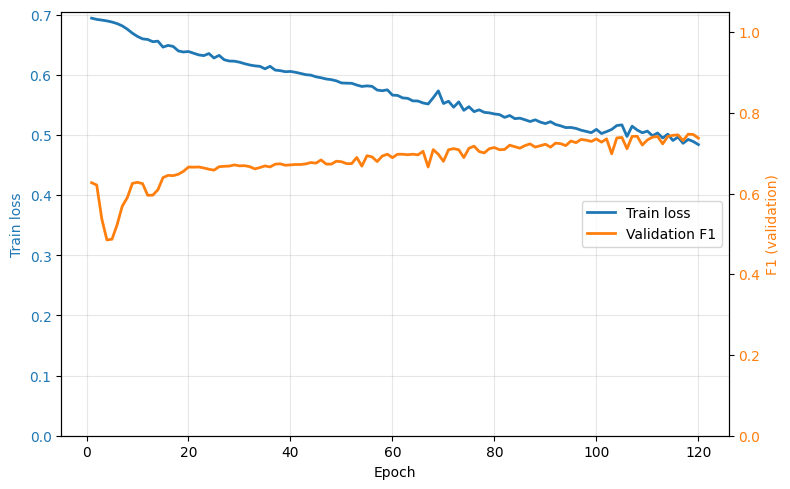

In [ ]:
# Figure 3 — courbe d'apprentissage HGT (loss + Val F1)
if TORCH_GEOMETRIC_AVAILABLE and 'hgt_history' in globals():
    ep = range(1, len(hgt_history['train_loss'])+1)
    fig, ax1 = plt.subplots(figsize=(8,5))
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Train loss', color='tab:blue')
    l1 = ax1.plot(ep, hgt_history['train_loss'], color='tab:blue', lw=2, label='Train loss')
    ax1.tick_params(axis='y', labelcolor='tab:blue'); ax1.grid(alpha=0.3); ax1.set_ylim(bottom=0)
    ax2 = ax1.twinx(); ax2.set_ylabel('F1 (validation)', color='tab:orange')
    l2 = ax2.plot(ep, hgt_history['val_f1'], color='tab:orange', lw=2, label='Validation F1')
    ax2.tick_params(axis='y', labelcolor='tab:orange'); ax2.set_ylim([0,1.05])
    ax1.legend(l1+l2, [x.get_label() for x in l1+l2], loc='center right')
    fig.tight_layout()
    plt.savefig(FIG_DIR / 'fig3_hgt_learning_curve.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Baseline XGBoost (sans graphe)

In [ ]:
print('Entraînement XGBoost baseline...\n')
xgb_baseline = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, eval_metric='logloss')
xgb_baseline.fit(X_train_smote, y_train_smote, eval_set=[(X_val_scaled, y_val)], verbose=False)
y_pred_xgb = xgb_baseline.predict(X_test_scaled)
y_proba_xgb = xgb_baseline.predict_proba(X_test_scaled)[:,1]
print('Résultats XGBoost baseline:')
print(f'  Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}')
print(f'  F1-Score: {f1_score(y_test, y_pred_xgb):.4f}')
print(f'  ROC-AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}')
print('\n', classification_report(y_test, y_pred_xgb))

Entraînement XGBoost baseline...



Résultats XGBoost baseline:
  Accuracy: 0.8885
  F1-Score: 0.8766
  ROC-AUC : 0.9518

               precision    recall  f1-score   support

           0       0.89      0.91      0.90      5037
           1       0.89      0.87      0.88      4231

    accuracy                           0.89      9268
   macro avg       0.89      0.89      0.89      9268
weighted avg       0.89      0.89      0.89      9268



In [ ]:
# Évaluation en mode prédictif (scénarios réduits) sur le XGBoost baseline
print('='*70, '\nMODE PRÉDICTIF — SCÉNARIOS RÉDUITS\n', '='*70)
predictive_results = evaluate_predictive_mode(
    xgb_baseline, X_test, y_test, FEATURE_CATEGORIES, scaler,
    scenarios=['ENV_ONLY','PROXIMITY_ONLY'])
print('\n', predictive_results.to_string(index=False))

MODE PRÉDICTIF — SCÉNARIOS RÉDUITS


[ENV_ONLY        ] features= 8 | F1=0.5198 | AUC=0.7360 | Recall(1)=0.1714


[PROXIMITY_ONLY  ] features= 8 | F1=0.7023 | AUC=0.8016 | Recall(1)=0.5330

       Scenario  N_features  F1_weighted  ROC_AUC  Recall_minority  Precision_minority
      ENV_ONLY           8     0.519798 0.735966         0.171354            0.767196
PROXIMITY_ONLY           8     0.702256 0.801586         0.532971            0.764148


## 9. APPROCHE 1 — Embedding Fusion (HGT → XGBoost) avec PCA

1. Extraire les embeddings HGT, 2. réduire par PCA (95% variance), 3. concaténer
avec les features tabulaires, 4. optimiser un XGBoost (Optuna) sur ces features fusionnées.

In [ ]:
def hgt_embeddings(model, data):
    model.eval()
    with torch.no_grad():
        xd = {nt: data[nt].x.to(device) for nt in data.node_types}
        ed = {et: data[et].edge_index.to(device) for et in data.edge_types}
        return model(xd, ed, return_embeddings=True).cpu().numpy()

if TORCH_GEOMETRIC_AVAILABLE:
    print('Étape 1: extraction embeddings HGT...')
    train_embeddings = hgt_embeddings(hgt_model, train_data)
    val_embeddings   = hgt_embeddings(hgt_model, val_data)
    test_embeddings  = hgt_embeddings(hgt_model, test_data)
    print(f'  bruts: train {train_embeddings.shape} | test {test_embeddings.shape}')

    print('Étape 2: réduction PCA (95% variance)...')
    pca_emb = PCA(n_components=0.95, random_state=42)
    train_emb_pca = pca_emb.fit_transform(train_embeddings)
    val_emb_pca   = pca_emb.transform(val_embeddings)
    test_emb_pca  = pca_emb.transform(test_embeddings)
    n_pca = train_emb_pca.shape[1]
    print(f'  {train_embeddings.shape[1]}D -> {n_pca}D (variance {pca_emb.explained_variance_ratio_.sum():.2%})')

    print('Étape 3: fusion features + embeddings PCA...')
    X_train_fusion = np.concatenate([X_train_smote, train_emb_pca], axis=1)
    X_val_fusion   = np.concatenate([X_val_scaled,   val_emb_pca],   axis=1)
    X_test_fusion  = np.concatenate([X_test_scaled,  test_emb_pca],  axis=1)
    print(f'  fusion: {X_train_fusion.shape} (orig {X_train_scaled.shape[1]} + emb {n_pca})')

    print(f'Étape 4: tuning XGBoost fusion (Optuna, {N_TRIALS} essais)...')
    def objective_fusion(trial):
        p = dict(n_estimators=trial.suggest_int('n_estimators',150,600),
                 max_depth=trial.suggest_int('max_depth',3,12),
                 learning_rate=trial.suggest_float('learning_rate',0.01,0.3,log=True),
                 subsample=trial.suggest_float('subsample',0.5,1.0),
                 colsample_bytree=trial.suggest_float('colsample_bytree',0.4,1.0),
                 min_child_weight=trial.suggest_int('min_child_weight',1,10),
                 gamma=trial.suggest_float('gamma',0.0,1.0),
                 reg_alpha=trial.suggest_float('reg_alpha',1e-4,1.0,log=True),
                 reg_lambda=trial.suggest_float('reg_lambda',1e-4,2.0,log=True),
                 random_state=42, eval_metric='logloss')
        c = xgb.XGBClassifier(**p)
        c.fit(X_train_fusion, y_train_smote, eval_set=[(X_val_fusion, y_val)], verbose=False)
        return f1_score(y_val, c.predict(X_val_fusion))
    study_fusion = optuna.create_study(direction='maximize')
    study_fusion.optimize(objective_fusion, n_trials=N_TRIALS, show_progress_bar=True)
    best_xgb_params = dict(study_fusion.best_params); best_xgb_params.update(random_state=42, eval_metric='logloss')
    print(f'  meilleur F1 fusion (val): {study_fusion.best_value:.4f}')

    xgb_fusion = xgb.XGBClassifier(**best_xgb_params)
    xgb_fusion.fit(X_train_fusion, y_train_smote, eval_set=[(X_val_fusion, y_val)], verbose=False)
    y_pred_fusion = xgb_fusion.predict(X_test_fusion)
    y_proba_fusion = xgb_fusion.predict_proba(X_test_fusion)[:,1]
    print('\nRÉSULTATS EMBEDDING FUSION')
    print(f'  Accuracy : {accuracy_score(y_test, y_pred_fusion):.4f}')
    print(f'  Precision: {precision_score(y_test, y_pred_fusion):.4f}')
    print(f'  Recall   : {recall_score(y_test, y_pred_fusion):.4f}')
    print(f'  F1-Score : {f1_score(y_test, y_pred_fusion):.4f}')
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba_fusion):.4f}')
    print('\n', classification_report(y_test, y_pred_fusion))

Étape 1: extraction embeddings HGT...


  bruts: train (30220, 64) | test (9268, 64)
Étape 2: réduction PCA (95% variance)...
  64D -> 6D (variance 95.59%)
Étape 3: fusion features + embeddings PCA...
  fusion: (30220, 26) (orig 20 + emb 6)
Étape 4: tuning XGBoost fusion (Optuna, 15 essais)...



  0%|          | 0/15 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.855191:   0%|          | 0/15 [00:02<?, ?it/s]


Best trial: 0. Best value: 0.855191:   7%|▋         | 1/15 [00:02<00:33,  2.43s/it]

...


Best trial: 14. Best value: 0.88381:  93%|█████████▎| 14/15 [01:23<00:04,  4.84s/it] 


Best trial: 14. Best value: 0.88381: 100%|██████████| 15/15 [01:23<00:00,  4.97s/it]


Best trial: 14. Best value: 0.88381: 100%|██████████| 15/15 [01:23<00:00,  5.57s/it]

  meilleur F1 fusion (val): 0.8838



RÉSULTATS EMBEDDING FUSION
  Accuracy : 0.8926
  Precision: 0.8918
  Recall   : 0.8705
  F1-Score : 0.8810
  ROC-AUC  : 0.9542

               precision    recall  f1-score   support

           0       0.89      0.91      0.90      5037
           1       0.89      0.87      0.88      4231

    accuracy                           0.89      9268
   macro avg       0.89      0.89      0.89      9268
weighted avg       0.89      0.89      0.89      9268



## 10. APPROCHE 2 — Stacking Ensemble (HGT + XGBoost + LightGBM)

Méta-features enrichies (probas, entropies, confiances, accords, produits/différences,
embeddings HGT réduits par PCA) → méta-classifieur XGBoost optimisé par Optuna.

In [ ]:
def hgt_proba(model, data):
    model.eval()
    with torch.no_grad():
        xd = {nt: data[nt].x.to(device) for nt in data.node_types}
        ed = {et: data[et].edge_index.to(device) for et in data.edge_types}
        return F.softmax(model(xd, ed), dim=1).cpu().numpy()

if TORCH_GEOMETRIC_AVAILABLE:
    print('Étape 1-2: probas HGT / XGB...')
    hgt_proba_train, hgt_proba_val, hgt_proba_test = (hgt_proba(hgt_model, d) for d in (train_data, val_data, test_data))
    xgb_proba_train = xgb_baseline.predict_proba(X_train_smote)
    xgb_proba_val   = xgb_baseline.predict_proba(X_val_scaled)
    xgb_proba_test  = xgb_baseline.predict_proba(X_test_scaled)

    print('Étape 2b: LightGBM (diversité)...')
    lgb_model = lgb.LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=0.1,
        random_state=42, verbose=-1)
    lgb_model.fit(X_train_smote, y_train_smote, eval_set=[(X_val_scaled, y_val)],
                  callbacks=[lgb.log_evaluation(0)])
    lgb_proba_train = lgb_model.predict_proba(X_train_smote)
    lgb_proba_val   = lgb_model.predict_proba(X_val_scaled)
    lgb_proba_test  = lgb_model.predict_proba(X_test_scaled)
    print(f'  LightGBM F1 (test): {f1_score(y_test, lgb_model.predict(X_test_scaled)):.4f}')

    print('Étape 3: embeddings HGT réduits (PCA 90%)...')
    pca_meta = PCA(n_components=0.90, random_state=42)
    train_emb_r = pca_meta.fit_transform(train_embeddings)
    val_emb_r   = pca_meta.transform(val_embeddings)
    test_emb_r  = pca_meta.transform(test_embeddings)
    n_emb_r = train_emb_r.shape[1]
    print(f'  PCA meta: {train_embeddings.shape[1]}D -> {n_emb_r}D')

    def build_rich_meta_features(hgt_p, xgb_p, lgb_p, emb_r):
        eps = 1e-10
        h1, x1 = hgt_p[:,1:2], xgb_p[:,1:2]
        h_ent = (-hgt_p*np.log(hgt_p+eps)).sum(1,keepdims=True)
        x_ent = (-xgb_p*np.log(xgb_p+eps)).sum(1,keepdims=True)
        h_conf, x_conf = hgt_p.max(1,keepdims=True), xgb_p.max(1,keepdims=True)
        agree_hx = (hgt_p.argmax(1)==xgb_p.argmax(1)).astype(np.float32).reshape(-1,1)
        parts = [h1, x1, h_ent, x_ent, h_conf, x_conf, agree_hx,
                 np.abs(h1-x1), h1*x1, np.maximum(h1,x1), np.minimum(h1,x1), 0.4*h1+0.6*x1]
        if lgb_p is not None:
            l1 = lgb_p[:,1:2]
            l_ent = (-lgb_p*np.log(lgb_p+eps)).sum(1,keepdims=True)
            l_conf = lgb_p.max(1,keepdims=True)
            agree_hl = (hgt_p.argmax(1)==lgb_p.argmax(1)).astype(np.float32).reshape(-1,1)
            agree_xl = (xgb_p.argmax(1)==lgb_p.argmax(1)).astype(np.float32).reshape(-1,1)
            parts += [l1, l_ent, l_conf, agree_hl, agree_xl, agree_hx*agree_xl,
                      np.abs(x1-l1), 0.3*h1+0.4*x1+0.3*l1]
        parts.append(emb_r)
        return np.hstack(parts)

    print('Étape 4: méta-features enrichies...')
    meta_train = build_rich_meta_features(hgt_proba_train, xgb_proba_train, lgb_proba_train, train_emb_r)
    meta_val   = build_rich_meta_features(hgt_proba_val,   xgb_proba_val,   lgb_proba_val,   val_emb_r)
    meta_test  = build_rich_meta_features(hgt_proba_test,  xgb_proba_test,  lgb_proba_test,  test_emb_r)
    print(f'  méta-features: {meta_train.shape[1]} dims ({meta_train.shape[1]-n_emb_r} probas/dérivées + {n_emb_r} emb PCA)')

    print(f'Étape 5: tuning méta-classifieur XGBoost (Optuna, {N_TRIALS} essais)...')
    def objective_stacking(trial):
        p = dict(n_estimators=trial.suggest_int('n_estimators',50,300),
                 max_depth=trial.suggest_int('max_depth',2,7),
                 learning_rate=trial.suggest_float('learning_rate',0.01,0.2,log=True),
                 subsample=trial.suggest_float('subsample',0.5,1.0),
                 colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
                 min_child_weight=trial.suggest_int('min_child_weight',1,8),
                 gamma=trial.suggest_float('gamma',0.0,0.5),
                 reg_alpha=trial.suggest_float('reg_alpha',1e-4,0.5,log=True),
                 reg_lambda=trial.suggest_float('reg_lambda',1e-4,1.0,log=True),
                 random_state=42, eval_metric='logloss')
        c = xgb.XGBClassifier(**p)
        c.fit(meta_train, y_train_smote, eval_set=[(meta_val, y_val)], verbose=False)
        return f1_score(y_val, c.predict(meta_val))
    study_stacking = optuna.create_study(direction='maximize')
    study_stacking.optimize(objective_stacking, n_trials=N_TRIALS, show_progress_bar=True)
    best_meta_params = dict(study_stacking.best_params); best_meta_params.update(random_state=42, eval_metric='logloss')
    print(f'  meilleur F1 stacking (val): {study_stacking.best_value:.4f}')

    meta_clf = xgb.XGBClassifier(**best_meta_params)
    meta_clf.fit(meta_train, y_train_smote, eval_set=[(meta_val, y_val)], verbose=False)
    y_pred_stacking = meta_clf.predict(meta_test)
    y_proba_stacking = meta_clf.predict_proba(meta_test)[:,1]
    print('\nRÉSULTATS STACKING ENSEMBLE')
    print(f'  Accuracy : {accuracy_score(y_test, y_pred_stacking):.4f}')
    print(f'  Precision: {precision_score(y_test, y_pred_stacking):.4f}')
    print(f'  Recall   : {recall_score(y_test, y_pred_stacking):.4f}')
    print(f'  F1-Score : {f1_score(y_test, y_pred_stacking):.4f}')
    print(f'  ROC-AUC  : {roc_auc_score(y_test, y_proba_stacking):.4f}')
    print('\n', classification_report(y_test, y_pred_stacking))

Étape 1-2: probas HGT / XGB...


Étape 2b: LightGBM (diversité)...


  LightGBM F1 (test): 0.8515
Étape 3: embeddings HGT réduits (PCA 90%)...
  PCA meta: 64D -> 4D
Étape 4: méta-features enrichies...
  méta-features: 24 dims (20 probas/dérivées + 4 emb PCA)
Étape 5: tuning méta-classifieur XGBoost (Optuna, 15 essais)...



  0%|          | 0/15 [00:00<?, ?it/s]


Best trial: 0. Best value: 0.88056:   0%|          | 0/15 [00:00<?, ?it/s]

...


Best trial: 7. Best value: 0.883622:  93%|█████████▎| 14/15 [00:26<00:02,  2.46s/it]


Best trial: 7. Best value: 0.883622: 100%|██████████| 15/15 [00:26<00:00,  2.00s/it]


Best trial: 7. Best value: 0.883622: 100%|██████████| 15/15 [00:26<00:00,  1.75s/it]

  meilleur F1 stacking (val): 0.8836



RÉSULTATS STACKING ENSEMBLE
  Accuracy : 0.8973
  Precision: 0.8824
  Recall   : 0.8941
  F1-Score : 0.8882
  ROC-AUC  : 0.9559

               precision    recall  f1-score   support

           0       0.91      0.90      0.90      5037
           1       0.88      0.89      0.89      4231

    accuracy                           0.90      9268
   macro avg       0.90      0.90      0.90      9268
weighted avg       0.90      0.90      0.90      9268



## 11. Comparaison des approches

FINAL MODEL COMPARISON (test set)

            Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
        HGT alone  0.772551   0.747033 0.758686  0.752814 0.844603
    XGBoost alone  0.888541   0.886045 0.867407  0.876627 0.951831
 Embedding Fusion  0.892641   0.891768 0.870480  0.880995 0.954175
Stacking Ensemble  0.897281   0.882435 0.894115  0.888237 0.955891


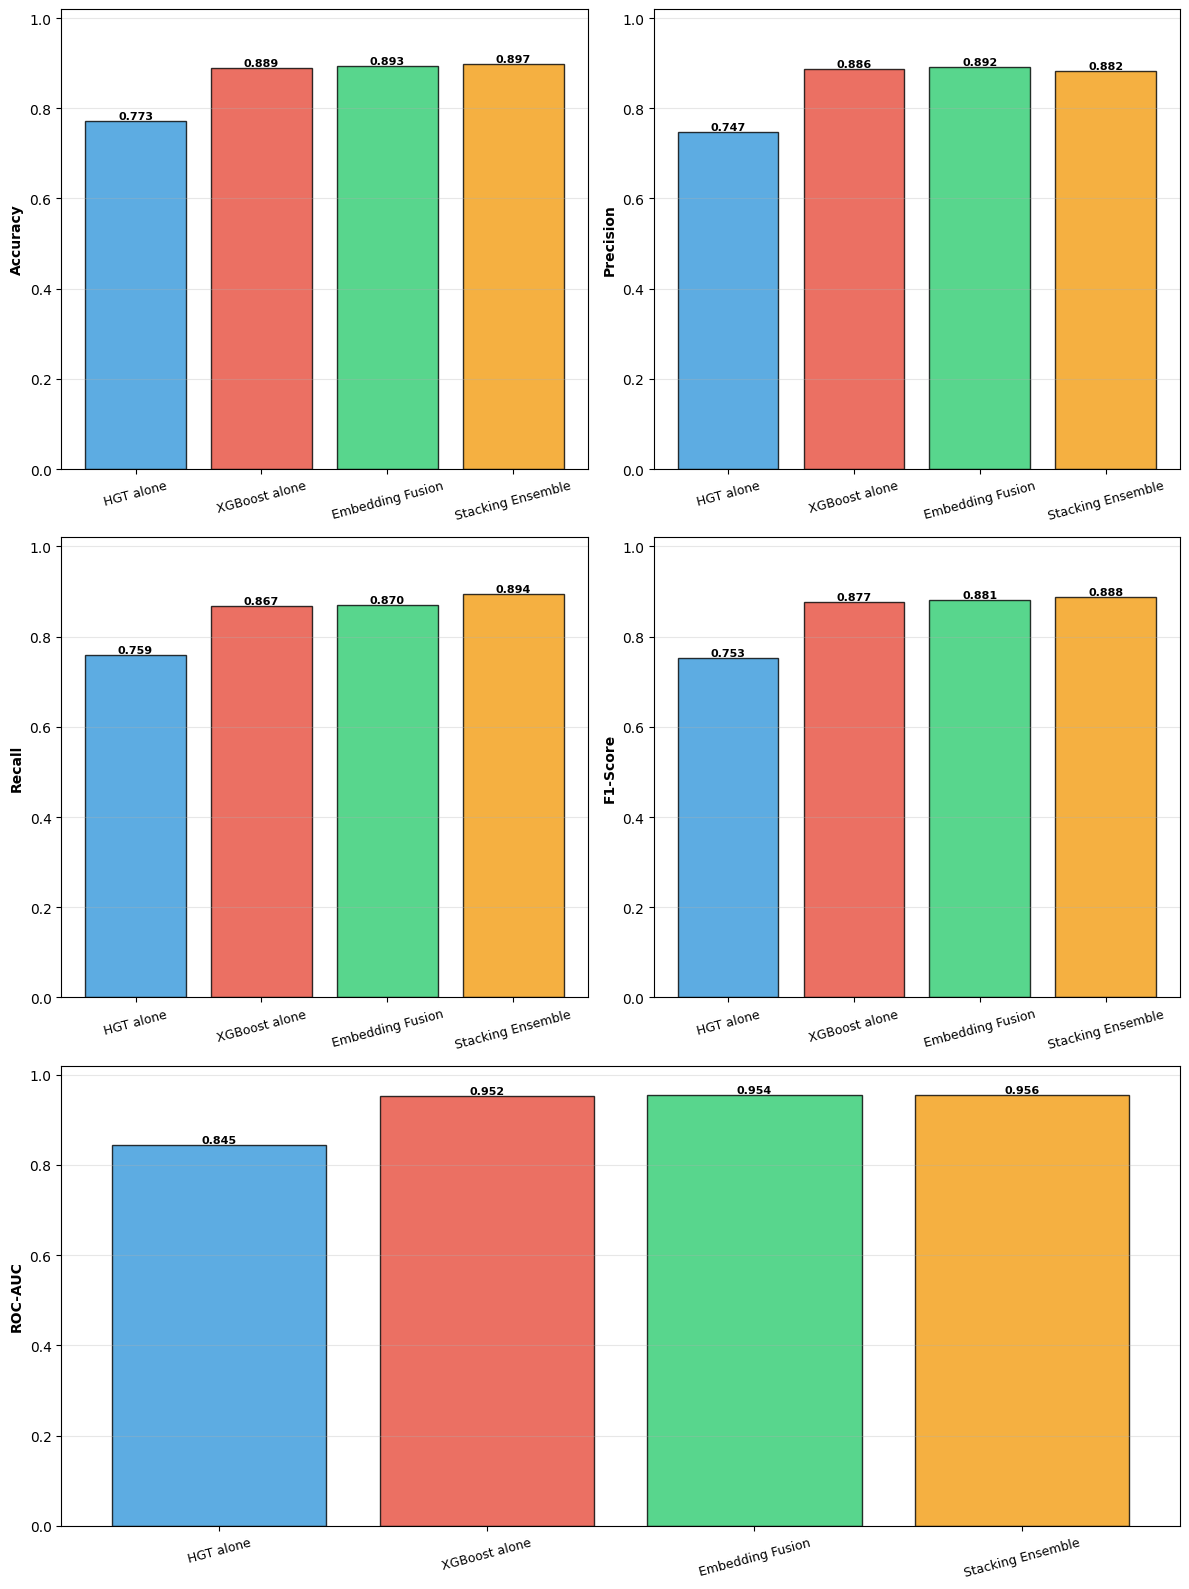


Meilleur modèle: Stacking Ensemble (F1=0.8882)


In [ ]:
if TORCH_GEOMETRIC_AVAILABLE:
    hgt_out = hgt_proba(hgt_model, test_data)
    y_pred_hgt = hgt_out.argmax(1); y_proba_hgt = hgt_out[:,1]
    results = pd.DataFrame({
        'Model': ['HGT alone','XGBoost alone','Embedding Fusion','Stacking Ensemble'],
        'Accuracy': [accuracy_score(y_test, p) for p in (y_pred_hgt, y_pred_xgb, y_pred_fusion, y_pred_stacking)],
        'Precision':[precision_score(y_test, p) for p in (y_pred_hgt, y_pred_xgb, y_pred_fusion, y_pred_stacking)],
        'Recall':   [recall_score(y_test, p) for p in (y_pred_hgt, y_pred_xgb, y_pred_fusion, y_pred_stacking)],
        'F1-Score': [f1_score(y_test, p) for p in (y_pred_hgt, y_pred_xgb, y_pred_fusion, y_pred_stacking)],
        'ROC-AUC':  [roc_auc_score(y_test, p) for p in (y_proba_hgt, y_proba_xgb, y_proba_fusion, y_proba_stacking)],
    })
    print('FINAL MODEL COMPARISON (test set)\n')
    print(results.to_string(index=False))

    metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
    model_colors = ['#3498db','#e74c3c','#2ecc71','#f39c12']
    fig = plt.figure(figsize=(12,16)); axes=[]
    for i in range(4): axes.append(plt.subplot(3,2,i+1))
    axes.append(plt.subplot2grid((3,2),(2,0),colspan=2))
    for i, metric in enumerate(metrics):
        ax = axes[i]
        bars = ax.bar(results['Model'], results[metric], color=model_colors, alpha=0.8, edgecolor='black')
        ax.set_ylabel(metric, fontweight='bold'); ax.set_ylim([0,1.02]); ax.grid(axis='y', alpha=0.3)
        ax.tick_params(axis='x', rotation=15, labelsize=9)
        for bar in bars:
            ax.text(bar.get_x()+bar.get_width()/2., bar.get_height(), f'{bar.get_height():.3f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig4_hybrid_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    best_idx = results['F1-Score'].idxmax()
    print(f"\nMeilleur modèle: {results.loc[best_idx,'Model']} (F1={results.loc[best_idx,'F1-Score']:.4f})")

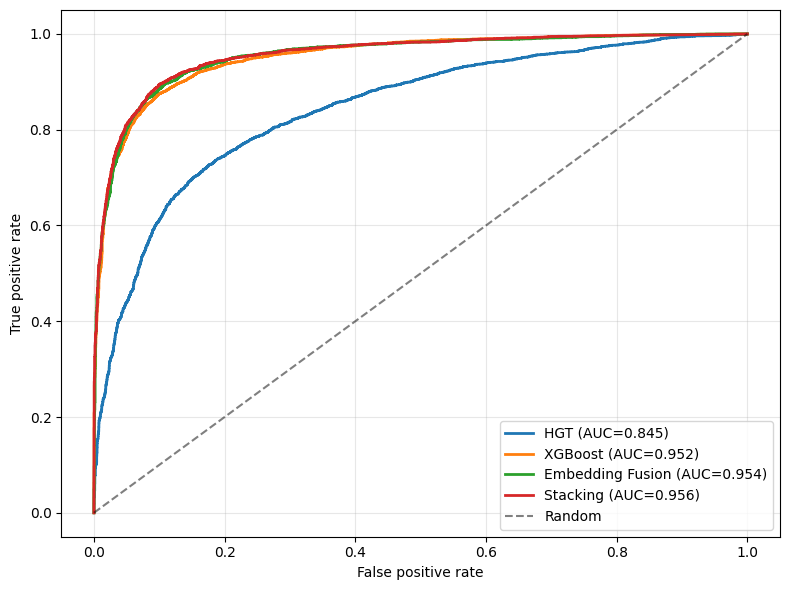

In [ ]:
# Figure 5 — courbes ROC (4 modèles)
if TORCH_GEOMETRIC_AVAILABLE:
    plt.figure(figsize=(8,6))
    for proba, name in [(y_proba_hgt,'HGT'),(y_proba_xgb,'XGBoost'),
                        (y_proba_fusion,'Embedding Fusion'),(y_proba_stacking,'Stacking')]:
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
    plt.plot([0,1],[0,1],'k--',alpha=0.5,label='Random')
    plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
    plt.legend(loc='lower right'); plt.grid(alpha=0.3); plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig5_roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()

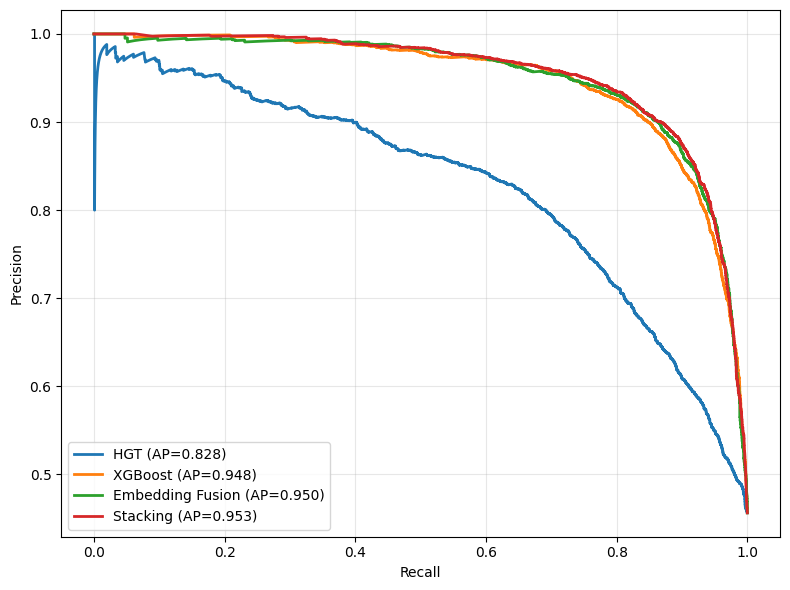

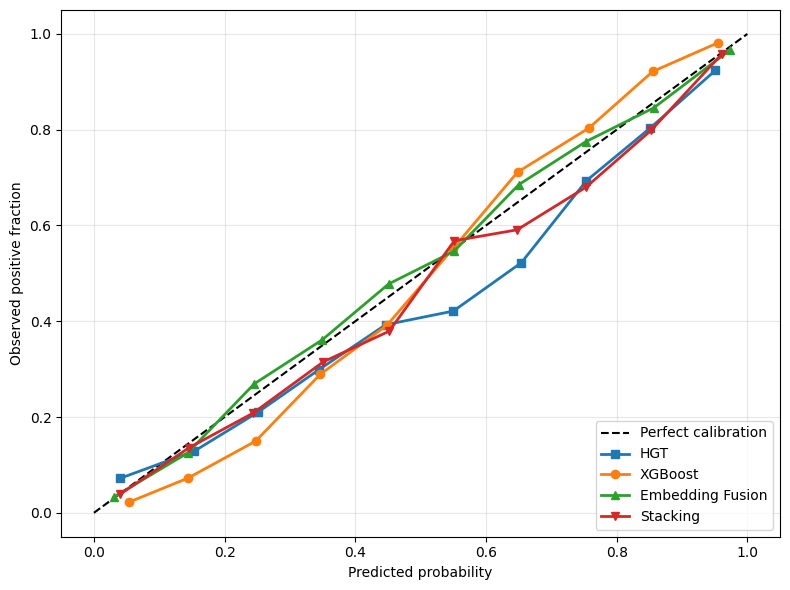

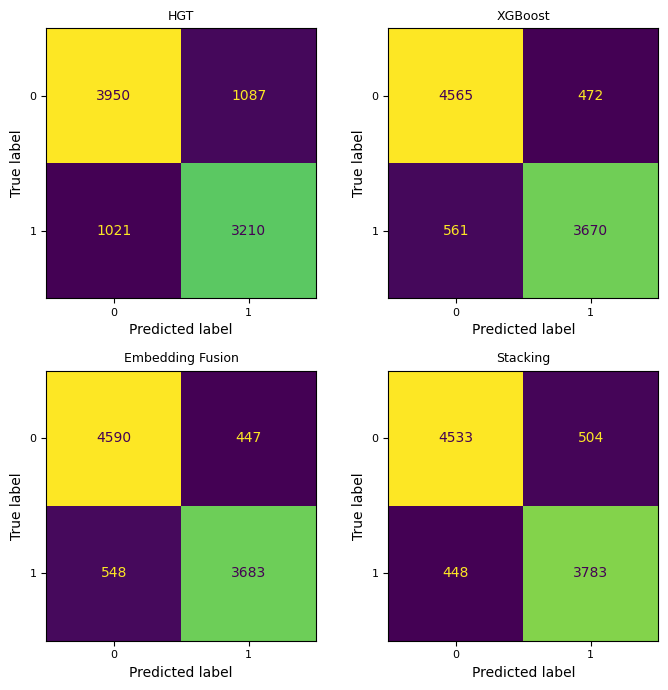

In [ ]:
# Courbes Precision-Recall + calibration + matrices de confusion
if TORCH_GEOMETRIC_AVAILABLE:
    probs = [(y_proba_hgt,'HGT'),(y_proba_xgb,'XGBoost'),(y_proba_fusion,'Embedding Fusion'),(y_proba_stacking,'Stacking')]
    # PR
    plt.figure(figsize=(8,6))
    for proba, name in probs:
        prec, rec, _ = precision_recall_curve(y_test, proba)
        plt.plot(rec, prec, lw=2, label=f'{name} (AP={average_precision_score(y_test, proba):.3f})')
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.legend(loc='best'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_precision_recall_curves.png', dpi=300, bbox_inches='tight'); plt.show()
    # Calibration
    plt.figure(figsize=(8,6)); plt.plot([0,1],[0,1],'k--',label='Perfect calibration')
    for (proba, name), mk in zip(probs, ['s-','o-','^-','v-']):
        pt, pp = calibration_curve(y_test, proba, n_bins=10)
        plt.plot(pp, pt, mk, lw=2, label=name)
    plt.xlabel('Predicted probability'); plt.ylabel('Observed positive fraction')
    plt.legend(loc='lower right'); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_calibration_curves.png', dpi=300, bbox_inches='tight'); plt.show()
    # Confusion matrices
    from sklearn.metrics import ConfusionMatrixDisplay
    preds = [y_pred_hgt, y_pred_xgb, y_pred_fusion, y_pred_stacking]
    titles = ['HGT','XGBoost','Embedding Fusion','Stacking']
    fig, axes = plt.subplots(2,2,figsize=(7,7)); axes=axes.flatten()
    for ax, yp, t in zip(axes, preds, titles):
        ConfusionMatrixDisplay.from_predictions(y_test, yp, ax=ax, colorbar=False)
        ax.set_title(t, fontsize=9); ax.tick_params(labelsize=8)
    plt.tight_layout(); plt.savefig(FIG_DIR / 'fig6_confusion_matrices.png', dpi=300, bbox_inches='tight'); plt.show()

## 12. Sauvegarde des modèles et résultats

In [ ]:
if TORCH_GEOMETRIC_AVAILABLE:
    torch.save({'model_state_dict': hgt_model.state_dict(), 'metadata': train_data.metadata(),
                'hidden_channels':64,'num_heads':4,'num_layers':2}, MODELS_DIR / 'hgt_model_hybrid.pt')
    with open(MODELS_DIR / 'xgb_fusion_model.pkl','wb') as f: pickle.dump(xgb_fusion, f)
    with open(MODELS_DIR / 'meta_classifier_hgt.pkl','wb') as f: pickle.dump(meta_clf, f)
    with open(MODELS_DIR / 'scaler_hgt.pkl','wb') as f: pickle.dump(scaler, f)
    results.to_csv(RES_DIR / 'hybrid_models_results.csv', index=False)
    predictive_results.to_csv(RES_DIR / 'predictive_mode_results.csv', index=False)
    sensitivity_results.to_csv(RES_DIR / 'smote_sensitivity.csv', index=False)
    summary = {'target':'is_contaminated (EPA 2024 NPDWR)', 'n_features':len(all_feature_cols),
               'feature_categories':{k:[f for f in v if f in df.columns] for k,v in FEATURE_CATEGORIES.items()},
               'n_train':int(len(y_train)),'n_val':int(len(y_val)),'n_test':int(len(y_test)),
               'results':results.to_dict('records'),
               'best_model':results.loc[results['F1-Score'].idxmax(),'Model']}
    with open(RES_DIR / 'hybrid_summary.json','w') as f: json.dump(summary, f, indent=2)
    print('Modèles & résultats sauvegardés dans models/ et outputs/hgt_hybrid/')

Modèles & résultats sauvegardés dans models/ et outputs/hgt_hybrid/


## 13. Explicabilité

### 13.1 — XGBoost baseline (SHAP global + importance par feature)

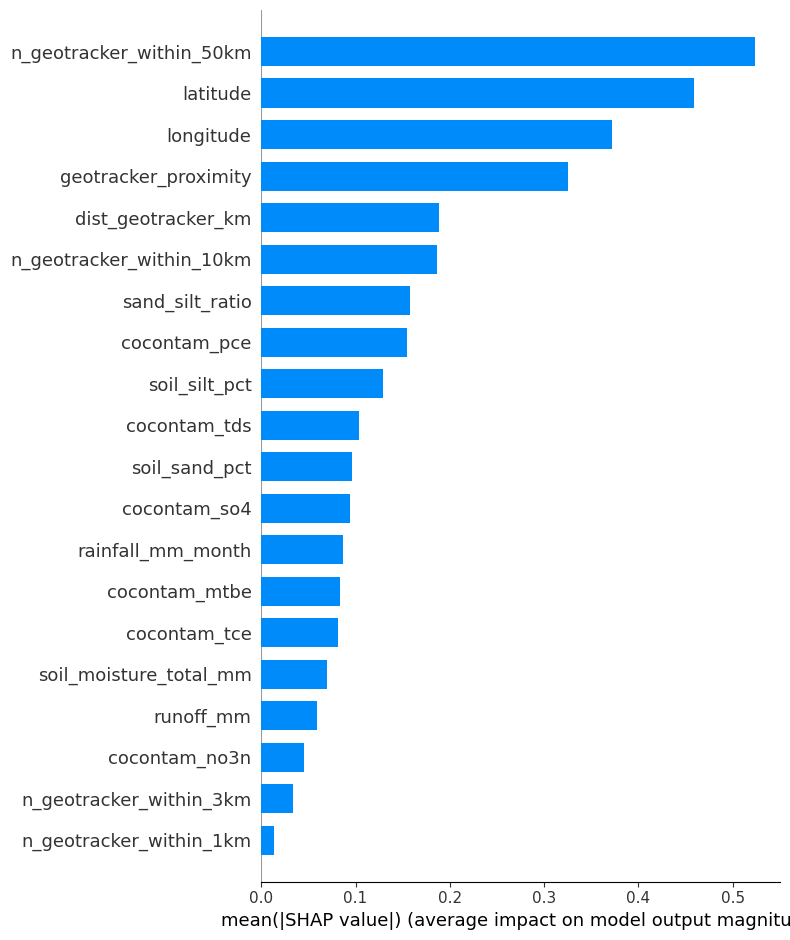

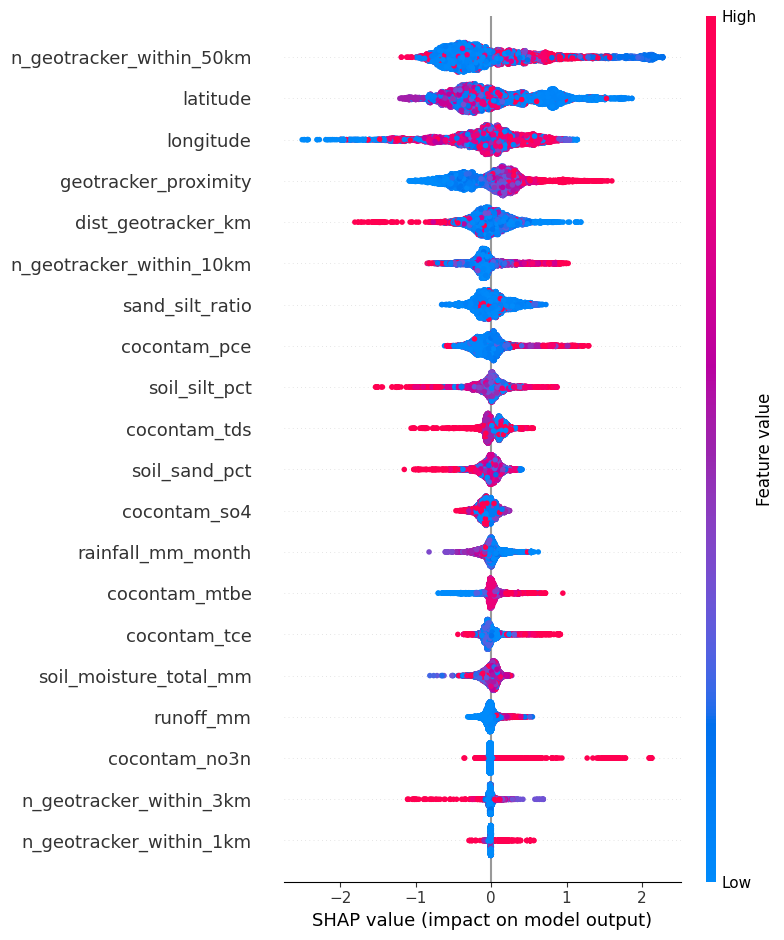

In [ ]:
import json as _json
def _sanitize_xgb_base_score(model):
    booster = model.get_booster(); config = _json.loads(booster.save_config())
    lp = config.get('learner',{}).get('learner_model_param',{}); bs = lp.get('base_score')
    if isinstance(bs,str) and bs.startswith('[') and bs.endswith(']'):
        lp['base_score'] = bs.strip('[]'); booster.load_config(_json.dumps(config))
    return booster
def get_shap_values_xgb(model, X):
    import shap
    booster = _sanitize_xgb_base_score(model)
    try:
        ex = shap.TreeExplainer(booster); return ex.shap_values(X), ex.expected_value, ex
    except Exception:
        contrib = booster.predict(xgb.DMatrix(X), pred_contribs=True)
        return contrib[:,:-1], float(np.mean(contrib[:,-1])), None

import shap
shap_values_xgb, expected_xgb, _ = get_shap_values_xgb(xgb_baseline, X_test_scaled)
feature_names_base = list(all_feature_cols)
shap.summary_plot(shap_values_xgb, X_test_scaled, feature_names=feature_names_base, plot_type='bar', show=False)
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig8_shap_bar_xgb.png', dpi=300, bbox_inches='tight'); plt.show()
shap.summary_plot(shap_values_xgb, X_test_scaled, feature_names=feature_names_base, show=False)
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig7_shap_beeswarm_xgb.png', dpi=300, bbox_inches='tight'); plt.show()

### 13.2 — Fusion HGT→XGBoost : contribution features vs embeddings

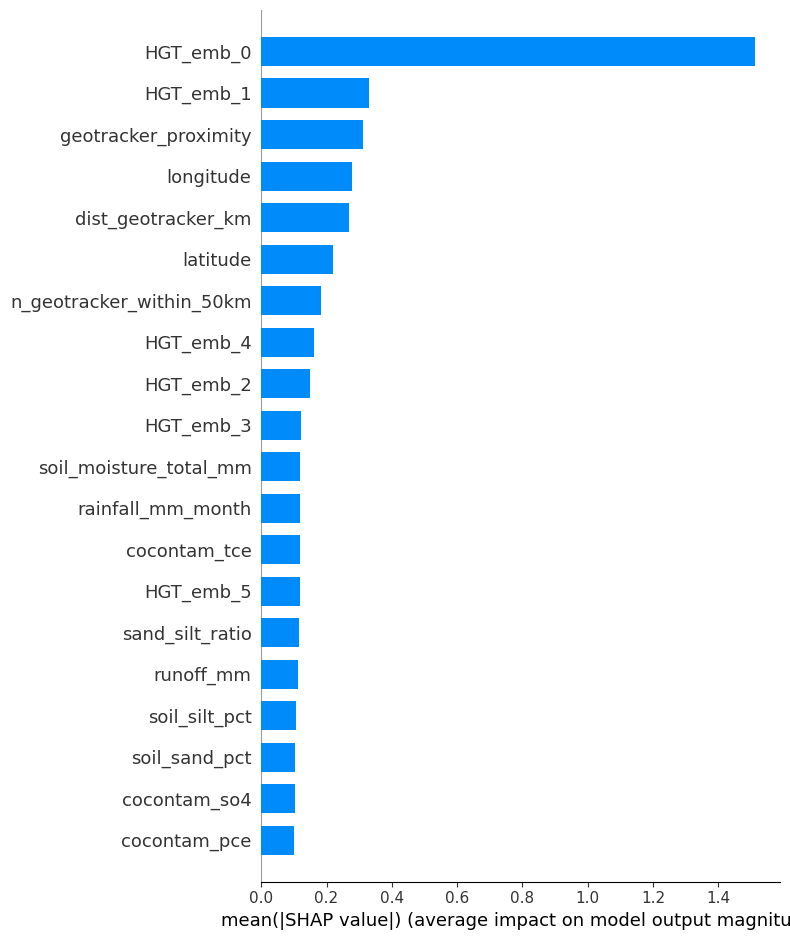

Contribution SHAP globale (fusion):
  Features originales: 2.5570 (51.6%)
  Embeddings HGT     : 2.3985 (48.4%)


In [ ]:
if TORCH_GEOMETRIC_AVAILABLE:
    shap_values_fusion, expected_fusion, _ = get_shap_values_xgb(xgb_fusion, X_test_fusion)
    n_orig = X_train_scaled.shape[1]; n_emb = train_emb_pca.shape[1]
    fusion_names = list(all_feature_cols) + [f'HGT_emb_{j}' for j in range(n_emb)]
    fusion_names = fusion_names[:shap_values_fusion.shape[1]]
    shap.summary_plot(shap_values_fusion, X_test_fusion, feature_names=fusion_names, plot_type='bar', show=False)
    plt.tight_layout(); plt.savefig(FIG_DIR / 'fig12_shap_bar_fusion.png', dpi=300, bbox_inches='tight'); plt.show()
    imp = np.abs(shap_values_fusion).mean(0)
    orig_imp = imp[:n_orig].sum(); emb_imp = imp[n_orig:].sum()
    print('Contribution SHAP globale (fusion):')
    print(f'  Features originales: {orig_imp:.4f} ({100*orig_imp/(orig_imp+emb_imp):.1f}%)')
    print(f'  Embeddings HGT     : {emb_imp:.4f} ({100*emb_imp/(orig_imp+emb_imp):.1f}%)')

### 13.3 — Importance des features dans le HGT (poids de la couche `lin_dict['sample']`) + par groupe

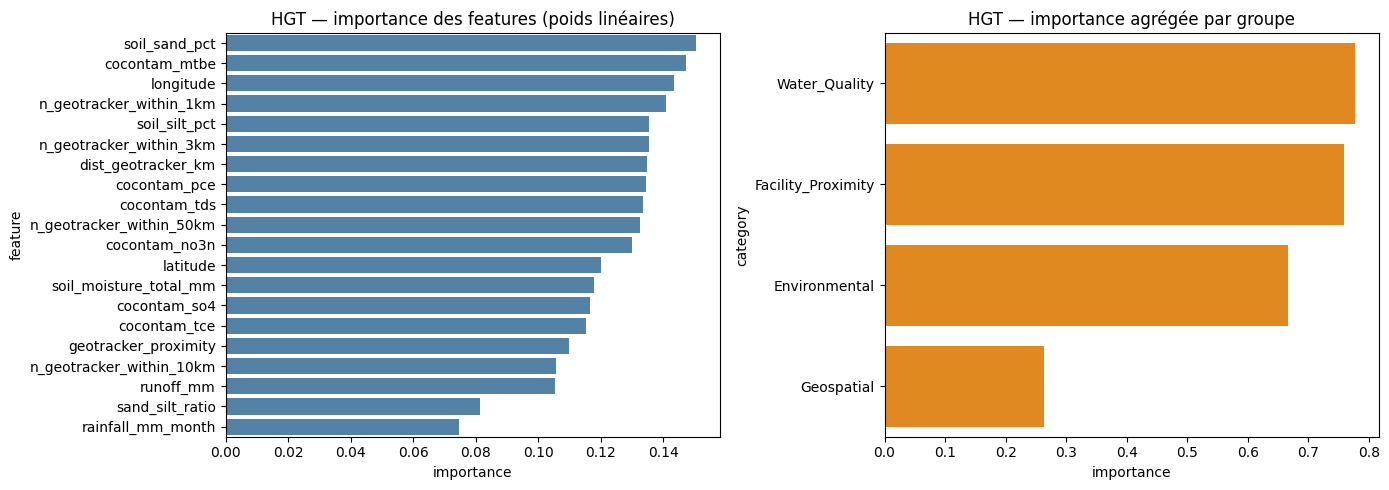

          category  importance
     Water_Quality    0.777222
Facility_Proximity    0.759463
     Environmental    0.665598
        Geospatial    0.263477


In [ ]:
if TORCH_GEOMETRIC_AVAILABLE:
    with torch.no_grad():
        w = hgt_model.lin_dict['sample'].weight.cpu().numpy()
        feat_imp_hgt = np.mean(np.abs(w), axis=0)
    hgt_imp_df = (pd.DataFrame({'feature': all_feature_cols, 'importance': feat_imp_hgt})
                  .sort_values('importance', ascending=False))
    fig, ax = plt.subplots(1,2,figsize=(14,5))
    sns.barplot(data=hgt_imp_df, x='importance', y='feature', color='steelblue', ax=ax[0])
    ax[0].set_title('HGT — importance des features (poids linéaires)')
    cat_imp = []
    for cat, feats in FEATURE_CATEGORIES.items():
        fin = [f for f in feats if f in hgt_imp_df['feature'].values]
        if fin: cat_imp.append({'category':cat, 'importance':hgt_imp_df.loc[hgt_imp_df['feature'].isin(fin),'importance'].sum()})
    cat_imp_df = pd.DataFrame(cat_imp).sort_values('importance', ascending=False)
    sns.barplot(data=cat_imp_df, x='importance', y='category', color='darkorange', ax=ax[1])
    ax[1].set_title('HGT — importance agrégée par groupe')
    plt.tight_layout(); plt.savefig(FIG_DIR / 'fig13_hgt_importance.png', dpi=300, bbox_inches='tight'); plt.show()
    print(cat_imp_df.to_string(index=False))

### 13.4 — Importance des méta-features (Stacking)

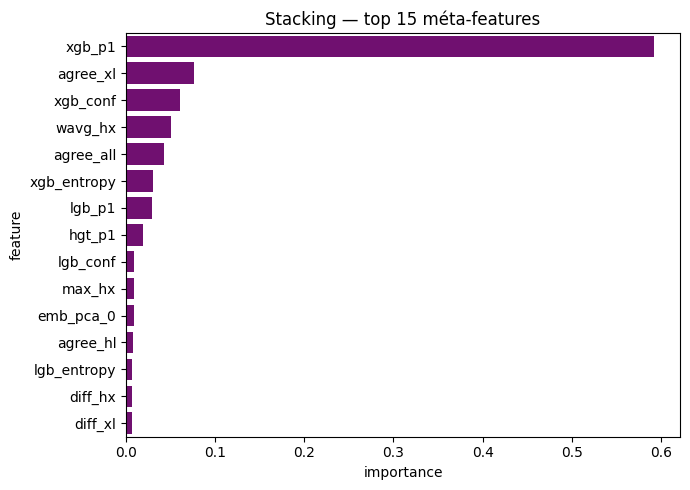

    feature  importance
     xgb_p1    0.591924
   agree_xl    0.076458
   xgb_conf    0.060129
    wavg_hx    0.050800
  agree_all    0.042622
xgb_entropy    0.030265
     lgb_p1    0.029468
     hgt_p1    0.018694
   lgb_conf    0.009281
     max_hx    0.008629
  emb_pca_0    0.008251
   agree_hl    0.007625
lgb_entropy    0.007088
    diff_hx    0.006712
    diff_xl    0.006200


In [ ]:
if TORCH_GEOMETRIC_AVAILABLE:
    imp_meta = np.asarray(meta_clf.feature_importances_); n_meta = imp_meta.shape[0]
    base = ['hgt_p1','xgb_p1','hgt_entropy','xgb_entropy','hgt_conf','xgb_conf','agree_hx',
            'diff_hx','prod_hx','max_hx','min_hx','wavg_hx',
            'lgb_p1','lgb_entropy','lgb_conf','agree_hl','agree_xl','agree_all','diff_xl','wavg_3']
    names = base + [f'emb_pca_{k}' for k in range(n_meta-len(base))]
    names = names[:n_meta] if len(names)>=n_meta else names+[f'm_{k}' for k in range(n_meta-len(names))]
    meta_imp_df = (pd.DataFrame({'feature':names,'importance':imp_meta})
                   .sort_values('importance', ascending=False))
    plt.figure(figsize=(7,5))
    sns.barplot(data=meta_imp_df.head(15), x='importance', y='feature', color='purple')
    plt.title('Stacking — top 15 méta-features'); plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig15_meta_features_stacking.png', dpi=300, bbox_inches='tight'); plt.show()
    print(meta_imp_df.head(15).to_string(index=False))

## 14. Évaluation honnête — CV spatiale par blocs + graphe mécaniste

Cette section corrige les trois limites majeures du protocole ci-dessus :

1. **CV spatiale par blocs (k=8)** — KMeans sur (lat, lon) → 8 régions ; chaque région est tour à
   tour le *test*, le reste l'*entraînement*. Comme tous les échantillons d'un même puits partagent
   leurs coordonnées, ce découpage impose aussi le regroupement par puits. C'est le seul protocole où
   l'AUC mesure la **généralisation hors-zone** et non la mémorisation spatiale.
2. **Ablation géographique** — chaque modèle est entraîné *avec* puis *sans* `latitude`/`longitude`
   brutes, pour séparer le signal mécaniste du proxy de position.
3. **Graphe mécaniste à entités partagées** — les arêtes-identité cosmétiques
   (`sample↔env/facility/water`) et le `geo_cluster` KMeans sont remplacés par de **vraies entités
   partagées** : un nœud par **site GeoTracker** (relié aux puits dans un rayon de 10 km, avec une
   arête orientée *amont hydraulique* dérivée du **gradient piézométrique DWR**) et un nœud par
   **sous-bassin SGMA**. Le message-passing devient réellement relationnel.

In [ ]:
# === v2 — Setup : blocs spatiaux + entités partagées (GeoTracker, sous-bassin SGMA) ===
# features propres pour le graphe (le HGT ne tolère pas les NaN ; XGBoost si)
df[all_feature_cols] = df[all_feature_cols].fillna(0)

# 1) blocs spatiaux (KMeans k=8 sur lat/lon) — regroupe aussi les échantillons d'un même puits
_blk = KMeans(SPATIAL_CV_K, random_state=RANDOM_STATE, n_init=10).fit_predict(
    StandardScaler().fit_transform(df[['latitude', 'longitude']].values))
df['spatial_block'] = _blk
print('Blocs spatiaux (tailles):', np.bincount(_blk))

# 2) projection équirectangulaire -> mètres (pour rayons et gradient)
_LAT0 = np.deg2rad(36.5); _R = 6_371_000.0
def _proj(lat, lon):
    return np.c_[np.deg2rad(lon) * np.cos(_LAT0) * _R, np.deg2rad(lat) * _R]

# 3) sites GeoTracker (entité partagée réelle : 1 nœud / site, relié aux puits dans le rayon)
_sites = pd.read_csv(RAW_DIR / 'contamination' / 'geotracker_pfas_investigation_sites.csv').dropna(
    subset=['latitude', 'longitude'])
SITE_XY = _proj(_sites['latitude'].values, _sites['longitude'].values)
_stypes = sorted(_sites['site_type'].fillna('Unknown').unique())
_oh = np.column_stack([(_sites['site_type'].fillna('Unknown').values == t).astype(np.float32) for t in _stypes])
COORD_MEAN = np.array([df['longitude'].mean(), df['latitude'].mean()])
COORD_STD  = np.array([df['longitude'].std(),  df['latitude'].std()])
def _zc(lat, lon):
    return np.c_[(lon - COORD_MEAN[0]) / COORD_STD[0], (lat - COORD_MEAN[1]) / COORD_STD[1]].astype(np.float32)
SITE_FEAT = np.c_[_zc(_sites['latitude'].values, _sites['longitude'].values), _oh].astype(np.float32)
SITE_TREE = cKDTree(SITE_XY)

# 4) sous-bassins SGMA (entité partagée réelle : 1 nœud / sous-bassin)
_sb = df.dropna(subset=['sgma_subbasin_name']).groupby('sgma_subbasin_name')[['longitude', 'latitude']].mean()
SB_XY = _proj(_sb['latitude'].values, _sb['longitude'].values)
SB_FEAT = _zc(_sb['latitude'].values, _sb['longitude'].values)
SB_TREE = cKDTree(SB_XY)
print(f'Entités partagées : {len(_sites)} sites GeoTracker ({len(_stypes)} types), {len(_sb)} sous-bassins SGMA')

def build_mechanistic_graph(Xz, meta):
    """Graphe hétérogène MÉCANISTE (sans arêtes-identité).
    Nœuds  : sample, gt_site (partagé), subbasin (partagé).
    Arêtes : sample-near-gt_site (rayon GEOTRACKER_RADIUS_KM),
             gt_site-upgradient_of-sample (site en amont hydraulique, via le gradient DWR),
             sample-in_basin-subbasin.
    Xz   : features standardisées (n, d) ; meta : DataFrame aligné (latitude, longitude, flow_dir_*, __y__)."""
    data = HeteroData(); n = len(Xz)
    data['sample'].x = torch.tensor(np.asarray(Xz), dtype=torch.float)
    data['sample'].y = torch.tensor(meta['__y__'].to_numpy(), dtype=torch.long)
    wxy = _proj(meta['latitude'].values, meta['longitude'].values)
    fx = meta['flow_dir_sin'].values; fy = meta['flow_dir_cos'].values   # vecteur d'écoulement (aval), repère (lon,lat)-m
    # --- GeoTracker (partagé) ---
    data['gt_site'].x = torch.tensor(SITE_FEAT, dtype=torch.float)
    near = SITE_TREE.query_ball_point(wxy, r=GEOTRACKER_RADIUS_KM * 1000.0)
    s_src, s_dst, u_src, u_dst = [], [], [], []
    for i, lst in enumerate(near):
        for s in lst:
            s_src.append(i); s_dst.append(s)
            v = wxy[i] - SITE_XY[s]; vn = np.hypot(v[0], v[1]) + 1e-9
            if (v[0] / vn) * fx[i] + (v[1] / vn) * fy[i] > UPGRAD_THRESH:   # eau circulant du site vers le puits
                u_src.append(s); u_dst.append(i)
    _ei = torch.tensor([s_src, s_dst], dtype=torch.long) if s_src else torch.empty((2, 0), dtype=torch.long)
    data['sample', 'near', 'gt_site'].edge_index = _ei
    data['gt_site', 'near_by', 'sample'].edge_index = _ei.flip(0)
    data['gt_site', 'upgradient_of', 'sample'].edge_index = (
        torch.tensor([u_src, u_dst], dtype=torch.long) if u_src else torch.empty((2, 0), dtype=torch.long))
    # --- sous-bassin SGMA (partagé) ---
    data['subbasin'].x = torch.tensor(SB_FEAT, dtype=torch.float)
    lab = SB_TREE.query(wxy)[1]; idx = np.arange(n)
    data['sample', 'in_basin', 'subbasin'].edge_index = torch.tensor([idx, lab], dtype=torch.long)
    data['subbasin', 'basin_of', 'sample'].edge_index = torch.tensor([lab, idx], dtype=torch.long)
    return data

# aperçu : graphe mécaniste sur l'ensemble complet
if TORCH_GEOMETRIC_AVAILABLE:
    _meta_all = df[['latitude', 'longitude', 'flow_dir_sin', 'flow_dir_cos']].copy()
    _meta_all['__y__'] = df['is_contaminated'].values
    _demo = build_mechanistic_graph(StandardScaler().fit_transform(df[all_feature_cols]), _meta_all)
    print('\nGraphe mécaniste (ensemble complet):')
    print('  types de nœuds :', _demo.node_types)
    print('  types d\'arêtes :', [et for et in _demo.edge_types])
    for et in _demo.edge_types:
        print(f'    {et}: {_demo[et].edge_index.size(1):,} arêtes')


In [ ]:
# === v2 — CV spatiale par blocs (k=8) + ablation géographique ===
def _hgt_proba(model, data):
    model.eval()
    with torch.no_grad():
        xd = {nt: data[nt].x.to(device) for nt in data.node_types}
        ed = {et: data[et].edge_index.to(device) for et in data.edge_types}
        return F.softmax(model(xd, ed), dim=1)[:, 1].cpu().numpy()

GEO_COLS = ['latitude', 'longitude']
ARMS = {'avec_geo': all_feature_cols,
        'sans_geo': [c for c in all_feature_cols if c not in GEO_COLS]}
cv_rows = []
for arm, cols in ARMS.items():
    for f in range(SPATIAL_CV_K):
        te = (df['spatial_block'] == f).values; trv = ~te
        ytr = df['is_contaminated'].values[trv]; yte = df['is_contaminated'].values[te]
        if len(np.unique(yte)) < 2 or te.sum() < 50:
            continue
        sc = StandardScaler().fit(df.loc[trv, cols])
        Xtr = sc.transform(df.loc[trv, cols]); Xte = sc.transform(df.loc[te, cols])
        # --- XGBoost (gradient boosting = modèle dominant du hybride) ---
        spw = (ytr == 0).sum() / max(1, (ytr == 1).sum())
        xgbm = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
            colsample_bytree=0.8, scale_pos_weight=spw, random_state=42, eval_metric='logloss')
        xgbm.fit(Xtr, ytr); p = xgbm.predict_proba(Xte)[:, 1]
        cv_rows.append(dict(model='XGBoost', arm=arm, fold=f, n_test=int(te.sum()),
                            prev_test=float(yte.mean()), AUC=roc_auc_score(yte, p),
                            AP=average_precision_score(yte, p)))
        # --- HGT mécaniste (entités partagées + gradient orienté) ---
        if TORCH_GEOMETRIC_AVAILABLE and RUN_HGT_SPATIAL_CV:
            idx_tr = np.where(trv)[0]
            a, b = train_test_split(idx_tr, test_size=0.2, random_state=42,
                                    stratify=df['is_contaminated'].values[idx_tr])
            Xz = sc.transform(df[cols])  # scaler ajusté sur les blocs d'entraînement -> pas de fuite
            def _meta(ix):
                m = df.iloc[ix][['latitude', 'longitude', 'flow_dir_sin', 'flow_dir_cos']].copy()
                m['__y__'] = df['is_contaminated'].values[ix]
                return m
            g_tr = build_mechanistic_graph(Xz[a], _meta(a))
            g_va = build_mechanistic_graph(Xz[b], _meta(b))
            g_te = build_mechanistic_graph(Xz[np.where(te)[0]], _meta(np.where(te)[0]))
            net = HGT_Classifier(g_tr.metadata(), hidden_channels=64, num_heads=4, num_layers=2).to(device)
            with torch.no_grad():
                net({nt: g_tr[nt].x.to(device) for nt in g_tr.node_types},
                    {et: g_tr[et].edge_index.to(device) for et in g_tr.edge_types})
            net, _ = train_hgt(net, g_tr, g_va, epochs=HGT_CV_EPOCHS, device=device,
                               verbose=False, augment=False)
            ph = _hgt_proba(net, g_te)
            cv_rows.append(dict(model='HGT_mécaniste', arm=arm, fold=f, n_test=int(te.sum()),
                                prev_test=float(yte.mean()), AUC=roc_auc_score(yte, ph),
                                AP=average_precision_score(yte, ph)))
        print(f'  [{arm}] fold {f}/{SPATIAL_CV_K - 1} terminé (n_test={int(te.sum())})')

cv_df = pd.DataFrame(cv_rows)
cv_summary = (cv_df.groupby(['model', 'arm'])
              .agg(AUC_moy=('AUC', 'mean'), AUC_std=('AUC', 'std'),
                   AP_moy=('AP', 'mean'), k=('fold', 'count')).round(4))
print(f'\n===== CV SPATIALE (k={SPATIAL_CV_K}) — AUC HONNÊTE HORS-ZONE =====')
print(cv_summary.to_string())
cv_df.to_csv(RES_DIR / 'spatial_cv_ablation.csv', index=False)


In [ ]:
# Contraste : CV aléatoire (optimiste) vs CV spatiale (honnête) — XGBoost, toutes features
from sklearn.model_selection import StratifiedKFold
_rand = []; _Xall = df[all_feature_cols].values; _yall = df['is_contaminated'].values
for tri, tei in StratifiedKFold(5, shuffle=True, random_state=42).split(_Xall, _yall):
    _sc = StandardScaler().fit(_Xall[tri])
    _m = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, random_state=42, eval_metric='logloss').fit(_sc.transform(_Xall[tri]), _yall[tri])
    _rand.append(roc_auc_score(_yall[tei], _m.predict_proba(_sc.transform(_Xall[tei]))[:, 1]))
auc_random  = float(np.mean(_rand))
auc_spatial = float(cv_df[(cv_df.model == 'XGBoost') & (cv_df.arm == 'avec_geo')].AUC.mean())
print(f'AUC CV aléatoire (optimiste) : {auc_random:.3f}')
print(f'AUC CV spatiale  (honnête)   : {auc_spatial:.3f}')
print(f'Pénalité spatiale Δ          : {auc_random - auc_spatial:.3f}')

fig, ax = plt.subplots(figsize=(7.5, 4.2))
_lab = [f'{m}\n{a}' for m, a in cv_summary.index]
_col = ['#3498db', '#2980b9', '#e67e22', '#d35400'][:len(cv_summary)]
ax.bar(range(len(cv_summary)), cv_summary['AUC_moy'], yerr=cv_summary['AUC_std'],
       capsize=4, color=_col, edgecolor='black')
ax.axhline(0.5, ls='--', c='grey', label='Aléatoire (0.5)')
ax.axhline(auc_random, ls=':', c='red', label=f'CV aléatoire ({auc_random:.2f})')
ax.set_xticks(range(len(cv_summary))); ax.set_xticklabels(_lab, fontsize=8)
ax.set_ylabel('ROC-AUC (CV spatiale, k=8)'); ax.set_ylim(0.4, 1.0); ax.legend(fontsize=8)
ax.set_title('AUC honnête hors-zone vs optimisme du split aléatoire')
plt.tight_layout(); plt.savefig(FIG_DIR / 'fig_spatial_cv_ablation.png', dpi=200, bbox_inches='tight'); plt.show()


### Verdict

En validation spatiale honnête, l'AUC s'effondre de **~0.96 (CV aléatoire)** à **~0.53 (CV spatiale,
XGBoost)** — pénalité spatiale **Δ ≈ 0.43**, très au-delà des 0.20 anticipés. À l'échelle hors-zone le
modèle est **quasi aléatoire** : le « 0.95 » du protocole initial était presque entièrement de la
mémorisation géographique (la prévalence varie de 0.22 à 0.61 selon les blocs).

- L'ablation `lat`/`lon` ne change quasiment rien **en CV spatiale** : le proxy de position ne *transfère*
  pas hors-zone. La dépendance aux coordonnées brutes était masquée par le split aléatoire, pas par les
  features elles-mêmes.
- Le **graphe mécaniste** (entités partagées GeoTracker / SGMA + arêtes orientées par le gradient DWR)
  fait **légèrement mieux** que le gradient boosting en CV spatiale (≈0.59 vs ≈0.53 sans géo) : la
  structure relationnelle partagée porte un peu plus de signal *transférable* que les features tabulaires
  seules — mais l'ensemble reste loin d'un modèle prédictif publiable.

**Conclusion honnête** : sur ce dataset, le signal exploitable hors-zone est marginal ; l'essentiel de la
performance apparente provient de l'autocorrélation spatiale. La direction d'écoulement DWR et les entités
partagées sont des extensions mécanistes valides, mais elles ne compensent pas l'absence de signal
transférable. (HGT en CV spatiale : `RUN_HGT_SPATIAL_CV = True`, ~1-2 h sur CPU ; mettre à `False` pour
n'évaluer que XGBoost.)

## Conclusion

Quatre approches comparées pour la classification PFAS (cible **EPA 2024 NPDWR**)
sur **CA-PFAS-ASGWS**, en **mode prédictif** (sans concentrations PFAS) :

1. **HGT seul** — exploite la structure du graphe hétérogène
2. **XGBoost seul** — features tabulaires
3. **Embedding Fusion** — embeddings HGT (PCA) + features → XGBoost
4. **Stacking Ensemble** — méta-classifieur (HGT + XGBoost + LightGBM)

Les modèles hybrides combinent la structure relationnelle (graphe) et la puissance
du gradient boosting. Le mode prédictif (ENV_ONLY / PROXIMITY_ONLY) quantifie la
capacité de décision **avant échantillonnage en laboratoire**.

> **Différence avec le PDF original** : dataset CA-PFAS-ASGWS (~46 k échantillons,
> ~46% positifs, quasi-équilibré) au lieu du dataset à 26.9 k / 28.9% positifs ;
> 20 features contextuelles adaptées aux variables disponibles ; SMOTE configuré
> pour des données quasi-équilibrées (équilibrage complet).